# Customer Churn Prediction

This project focuses on predicting customer churn using machine learning.

The goal is to analyze customer characteristics and service information, identify patterns associated with churn, and build classification models that can predict whether a customer is likely to leave.

The project covers the complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model training, evaluation, comparison, and model saving.

## Project Objectives

The main objectives of this project are:

- Understand the customer churn dataset and its features.
- Clean and prepare the data for machine learning.
- Explore patterns and relationships related to customer churn.
- Encode categorical variables into numerical features.
- Train multiple classification models.
- Evaluate model performance using appropriate classification metrics.
- Compare Logistic Regression, Decision Tree, and Random Forest.
- Identify the most important features associated with churn.
- Extract business insights from the analysis.
- Save the trained model for future predictions.

## 1. Import Libraries

In this step, we import the libraries required for data manipulation, numerical operations, and data visualization.

In [30]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 2. Load the Dataset

In this step, we load the customer churn dataset into a Pandas DataFrame for further analysis and preprocessing.

In [31]:
df = pd.read_csv('customer_churn_data.csv')

### Preview the Dataset

In this step, we display the first few rows of the dataset to get an initial look at its structure and the available features.

In [32]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


### Dataset Overview

In this step, we examine the dataset's dimensions, data types, and statistical summary to better understand its structure and the characteristics of its features.

In [33]:
df.shape

(1000, 10)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 104.5 KB


In [35]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [36]:
df.nunique()

CustomerID         1000
Age                  57
Gender                2
Tenure               87
MonthlyCharges      935
ContractType          3
InternetService       2
TotalCharges        943
TechSupport           2
Churn                 2
dtype: int64

## 3. Data Cleaning

In this step, we check the dataset for missing values, duplicates, and other data quality issues before continuing with the analysis.

In [37]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.isnull().sum().sort_values(ascending=False)

InternetService    297
CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [40]:
df['InternetService']

0      Fiber Optic
1      Fiber Optic
2      Fiber Optic
3              DSL
4              NaN
          ...     
995    Fiber Optic
996            NaN
997    Fiber Optic
998            NaN
999            NaN
Name: InternetService, Length: 1000, dtype: str

In [41]:
df['InternetService']=df['InternetService'].fillna('None')

In [42]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

## 4. Exploratory Data Analysis

In this step, we explore the dataset to identify patterns, distributions, and relationships between customer features and churn.

In [43]:
df['Churn'].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

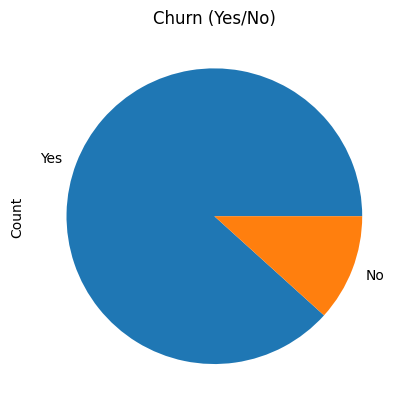

In [44]:
#plt.figure(figsize=(10,8),dpi=150)
df['Churn'].value_counts().plot(kind='pie')
plt.title('Churn (Yes/No)')
plt.ylabel('Count')
plt.show();

In [46]:
df['Churn']=df['Churn'].apply(lambda x : 1 if x =='Yes' else 0)
df['Churn']

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Churn, Length: 1000, dtype: int64

In [47]:
Numeric_columns_data = df.select_dtypes(include='number')
Numeric_columns_data 

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn
0,1,49,4,88.35,353.40,1
1,2,43,0,36.67,0.00,1
2,3,51,2,63.79,127.58,1
3,4,60,8,102.34,818.72,1
4,5,42,32,69.01,2208.32,1
...,...,...,...,...,...,...
995,996,42,41,37.14,1522.74,1
996,997,62,9,80.93,728.37,1
997,998,51,15,111.72,1675.80,1
998,999,39,68,65.67,4465.56,1


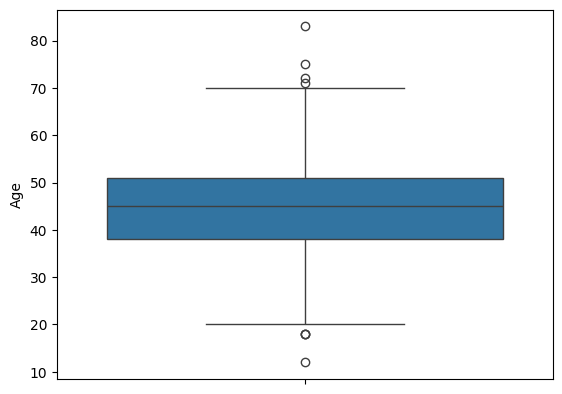

In [51]:
sns.boxplot(df,y='Age')
plt.show()

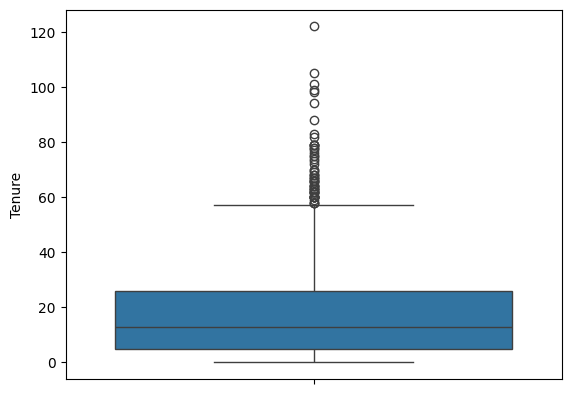

In [52]:
sns.boxplot(df,y='Tenure')
plt.show()

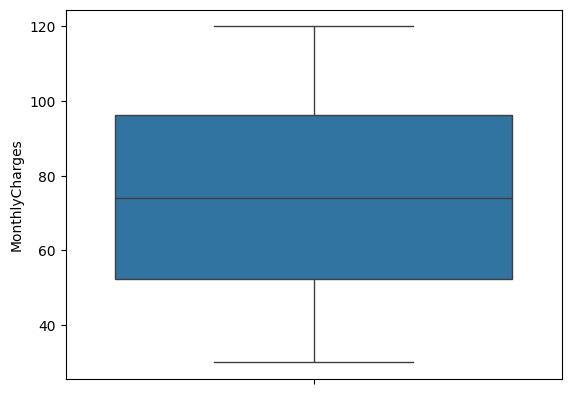

In [53]:
sns.boxplot(df,y='MonthlyCharges')
plt.show()

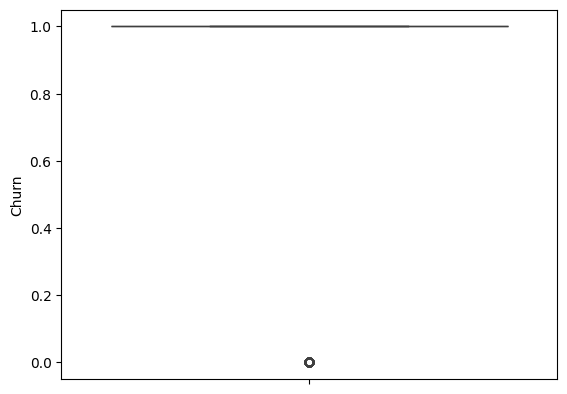

In [54]:
sns.boxplot(df,y='Churn')
plt.show()

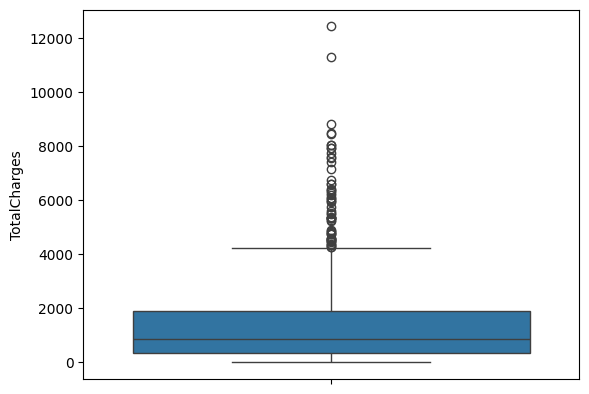

In [55]:
sns.boxplot(df,y='TotalCharges')
plt.show()

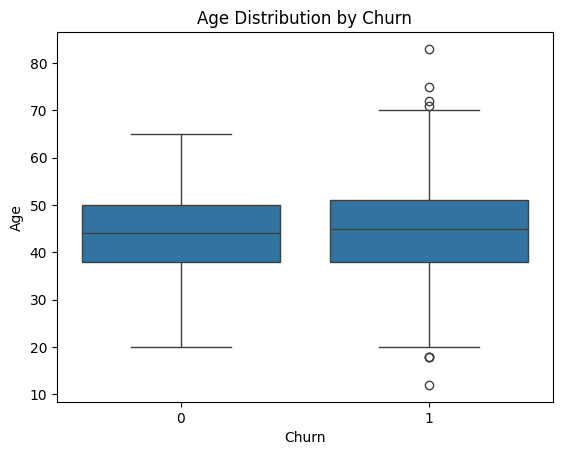

In [56]:
sns.boxplot(data=df, x='Churn', y='Age')

plt.title('Age Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Age')
plt.show()

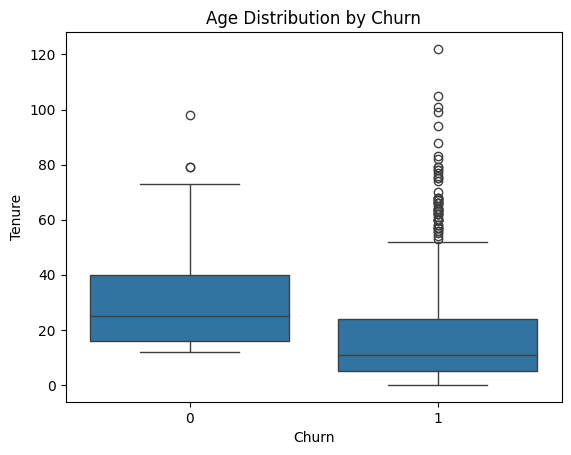

In [57]:
sns.boxplot(data=df, x='Churn', y='Tenure')

plt.title('Age Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

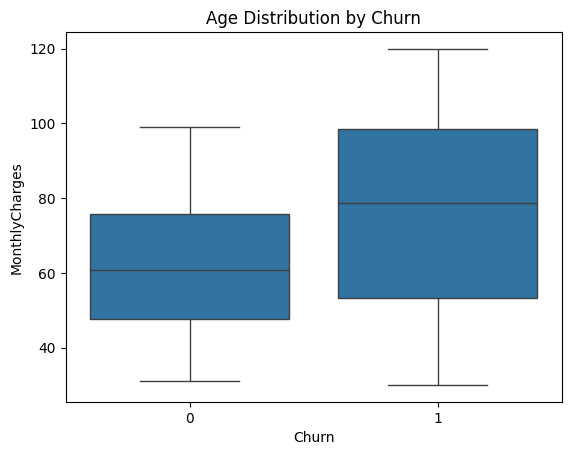

In [58]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Age Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('MonthlyCharges')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

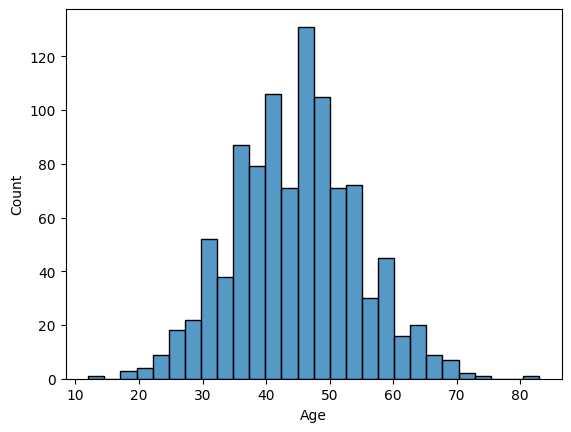

In [59]:
sns.histplot(df['Age'])


<Axes: xlabel='Tenure', ylabel='Count'>

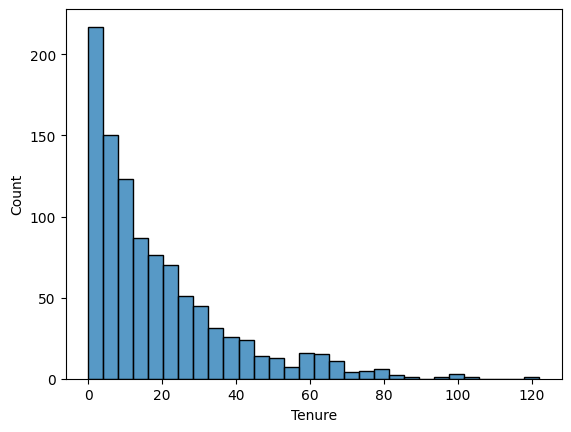

In [60]:
sns.histplot(df['Tenure'])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

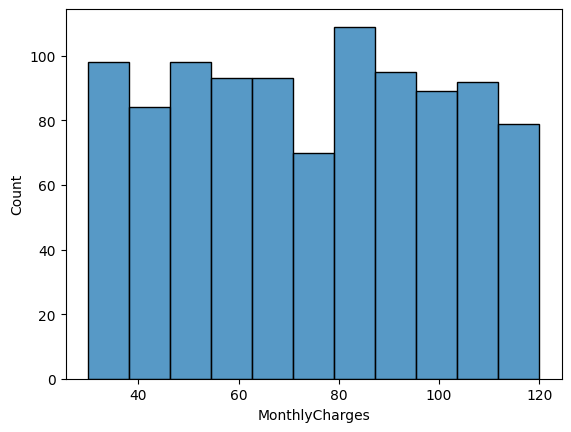

In [61]:
sns.histplot(df['MonthlyCharges'])

<Axes: xlabel='Churn', ylabel='Count'>

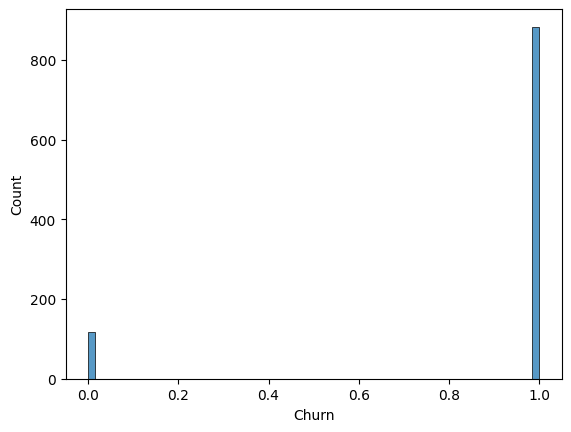

In [62]:
sns.histplot(df['Churn'])

<Axes: xlabel='TotalCharges', ylabel='Count'>

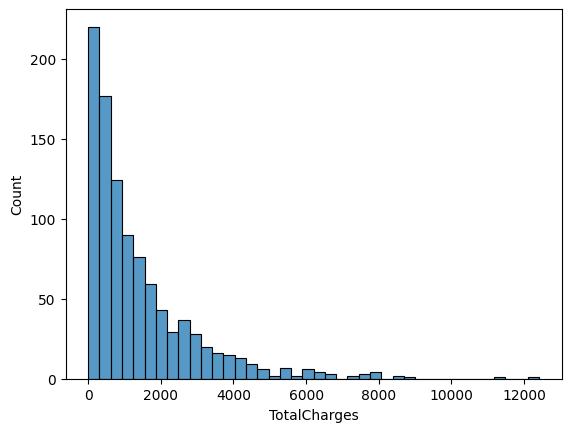

In [63]:
sns.histplot(df['TotalCharges'])

In [65]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='str')

In [68]:
df.drop(columns=['CustomerID'], inplace=True)

In [69]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType',
       'InternetService', 'TotalCharges', 'TechSupport', 'Churn'],
      dtype='str')

In [70]:
corr= df.corr(numeric_only=True)
corr

,Age,Tenure,MonthlyCharges,TotalCharges,Churn
Age,1.000000,0.000472,0.006362,-0.001896,0.044115
Tenure,0.000472,1.000000,-0.014552,0.894868,-0.217675
MonthlyCharges,0.006362,-0.014552,1.000000,0.304893,0.167773
TotalCharges,-0.001896,0.894868,0.304893,1.000000,-0.101523
Churn,0.044115,-0.217675,0.167773,-0.101523,1.000000


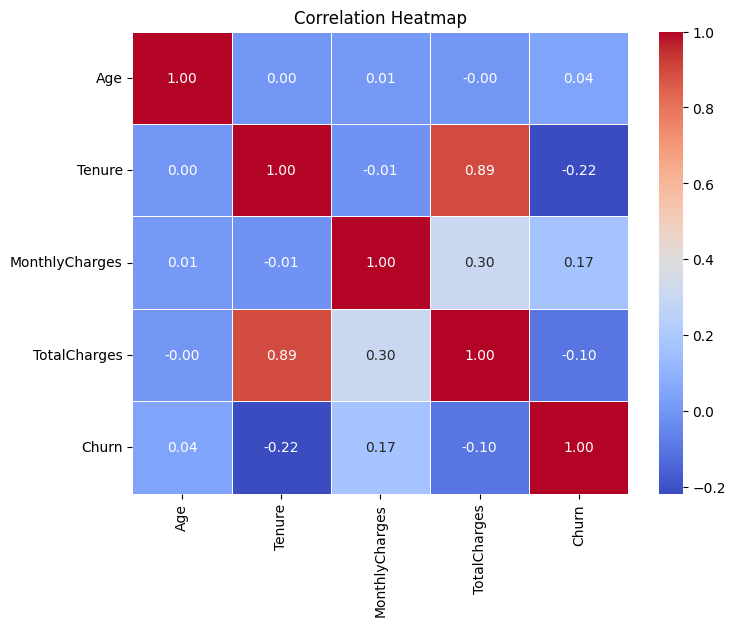

In [72]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

- **Tenure and TotalCharges** show a strong positive correlation (0.89), indicating that customers who stay longer tend to accumulate higher total charges.
- **Tenure and Churn** have a weak negative correlation (-0.22), suggesting that customers with longer tenure tend to churn slightly less.
- **MonthlyCharges and Churn** have a weak positive correlation (0.17), indicating a slight association between higher monthly charges and churn.
- **Age and Churn** have almost no linear correlation (0.04), suggesting that Age has little linear relationship with churn in this dataset.
- **Age** also shows almost no correlation with the other numerical features.

In [74]:
df['TotalCharges'].describe()

count     1000.000000
mean      1404.364060
std       1571.755048
min          0.000000
25%        345.217500
50%        872.870000
75%       1900.175000
max      12416.250000
Name: TotalCharges, dtype: float64

In [75]:
df.sort_values('TotalCharges', ascending = False).head(10)

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
493,36,Female,105,118.25,Month-to-Month,DSL,12416.25,Yes,1
540,53,Male,99,113.93,Month-to-Month,None,11279.07,No,1
509,36,Female,75,117.28,One-Year,DSL,8796.00,No,1
233,38,Female,122,69.58,Month-to-Month,DSL,8488.76,No,1
440,48,Male,94,89.57,One-Year,Fiber Optic,8419.58,No,1
136,37,Female,82,98.11,Month-to-Month,Fiber Optic,8045.02,No,1
617,52,Male,68,118.05,Month-to-Month,Fiber Optic,8027.40,Yes,1
771,39,Male,67,118.12,Month-to-Month,Fiber Optic,7914.04,Yes,1
741,32,Male,78,101.44,Two-Year,None,7912.32,No,1
689,49,Male,68,113.74,Month-to-Month,DSL,7734.32,Yes,1


### Total Charges Insights

- The top 10 customers by `TotalCharges` all have a churn value of 1; however, this subset alone does not indicate that higher total charges cause churn.
- Most customers in this top 10 group have a Month-to-Month contract (7 out of 10).
- `TotalCharges` has a wide range, from 0 to 12,416.25, with a median of 872.87 and a mean of 1,404.36.
- The mean being considerably higher than the median suggests that `TotalCharges` is right-skewed, with some customers having substantially higher total charges.

### Feature Encoding

In this step, we convert categorical features into numerical values using one-hot encoding so they can be used by the machine learning models.

In [78]:
df=pd.get_dummies(df,drop_first=True , dtype=int)

In [82]:
df.shape

(1000, 11)

### Define Features and Target

In this step, we separate the dataset into the input features (`X`) and the target variable (`y`) that the machine learning models will use for training and prediction.

In [80]:
X= df.drop('Churn',axis=1)
y=df['Churn']

In [81]:
X.shape

(1000, 10)

In [83]:
y.shape

(1000,)

### Train/Test Split

In this step, we split the dataset into training and testing sets to prepare the data for model training and evaluation.

In [84]:
from sklearn.model_selection import train_test_split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

### Feature Scaling

In this step, we import `StandardScaler` to standardize numerical features before training models that are sensitive to feature scale.

In [88]:
from sklearn.preprocessing import StandardScaler

In [89]:
scaler= StandardScaler()

In [90]:
scaled_X_train =scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

### Logistic Regression

In this step, we import `LogisticRegression` to build a classification model that predicts whether a customer will churn.

In [91]:
from sklearn.linear_model import LogisticRegression

In [92]:
log_model = LogisticRegression()

In [93]:
log_model.fit(scaled_X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [94]:
log_pred = log_model.predict(scaled_X_test)

In [95]:
log_pred[:5]

array([1, 1, 1, 1, 1])

In [96]:
y_test[:5]

521    1
737    1
740    1
660    1
411    1
Name: Churn, dtype: int64

### Model Evaluation Metrics

In this step, we import evaluation metrics to measure the performance of the classification models and analyze their prediction results.

In [97]:
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report

In [98]:
accuracy_score(y_test,log_pred)

0.955

In [99]:
confusion_matrix(y_test,log_pred)

array([[ 17,   6],
       [  3, 174]])

In [101]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79        23
           1       0.97      0.98      0.97       177

    accuracy                           0.95       200
   macro avg       0.91      0.86      0.88       200
weighted avg       0.95      0.95      0.95       200



### Logistic Regression Performance

The Logistic Regression churn model achieved **95.5% accuracy** on the test set. It performed strongly on the majority **non-churn class**, with **97% precision** and **98% recall**. However, recall for the minority **churn class was 74%**, meaning the model missed some customers who actually churned. This is partly related to the class imbalance in the test set, which contained **23 churned customers compared with 177 non-churned customers**.

In [103]:
from sklearn.metrics import roc_auc_score

y_prob = log_model.predict_proba(scaled_X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9845246868091377


In [104]:
print(log_model.classes_)

[0 1]


In [108]:
print(log_model.predict_proba(X_test)[:, 1])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


C:\Users\moham\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Decision Tree

In this step, we import `DecisionTreeClassifier` to build a tree-based classification model for predicting customer churn.

In [109]:
from  sklearn.tree import DecisionTreeClassifier

In [111]:
tree_model=DecisionTreeClassifier(random_state=42)

In [112]:
tree_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [113]:
tree_pred =tree_model.predict(X_test)

In [114]:
accuracy_score(y_test,tree_pred)

0.995

In [115]:
confusion_matrix(y_test,tree_pred)

array([[ 23,   0],
       [  1, 176]])

In [117]:
print(classification_report(y_test,tree_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.99      1.00       177

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [120]:
tree_model.score(X_train, y_train)

1.0

In [121]:
tree_model.score(X_test,y_test)

0.995

In [124]:
tree_prob = tree_model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, tree_prob))

ROC-AUC: 0.9971751412429379


### Decision Tree Performance

The Decision Tree model achieved **99.5% accuracy** and a **ROC-AUC of 0.997** on the test set, showing very strong classification performance. However, the model achieved **100% accuracy on the training set**, which may indicate **overfitting**. Therefore, the model's performance should be interpreted carefully and compared with other models such as Random Forest.

### Random Forest

In this step, we import `RandomForestClassifier` to build an ensemble classification model for predicting customer churn.

In [125]:
from sklearn.ensemble import RandomForestClassifier

In [126]:
rf= RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [127]:
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:
rf_pred= rf.predict(X_test)

In [129]:
accuracy_score(y_test,rf_pred)

1.0

In [130]:
confusion_matrix(y_test,rf_pred)

array([[ 23,   0],
       [  0, 177]])

In [132]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [133]:
rf_prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 1.0


In [134]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [135]:
importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,Tenure,0.183255
5,ContractType_One-Year,0.174667
9,TechSupport_Yes,0.167355
2,MonthlyCharges,0.147185
6,ContractType_Two-Year,0.136192
3,TotalCharges,0.107250
0,Age,0.037867
8,InternetService_None,0.023521
7,InternetService_Fiber Optic,0.012664
4,Gender_Male,0.010045


In [136]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

Churn                          1.000000
InternetService_None           0.236599
MonthlyCharges                 0.167773
Age                            0.044115
Gender_Male                    0.031539
TotalCharges                  -0.101523
InternetService_Fiber Optic   -0.145011
ContractType_Two-Year         -0.175782
Tenure                        -0.217675
ContractType_One-Year         -0.255231
TechSupport_Yes               -0.359667
Name: Churn, dtype: float64

### Random Forest Performance

The Random Forest model achieved **100% accuracy** and a **ROC-AUC of 1.000** on the test set, with no misclassifications among the **200 test samples**. While these results indicate excellent performance on the test set, the unusually perfect scores should be interpreted carefully and checked for potential **data leakage or other issues in the data preparation process** before considering them as final model results.

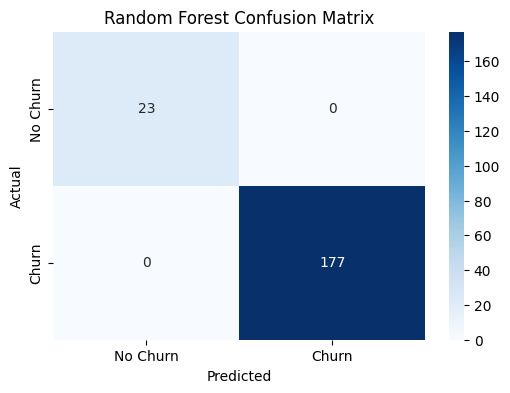

In [137]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

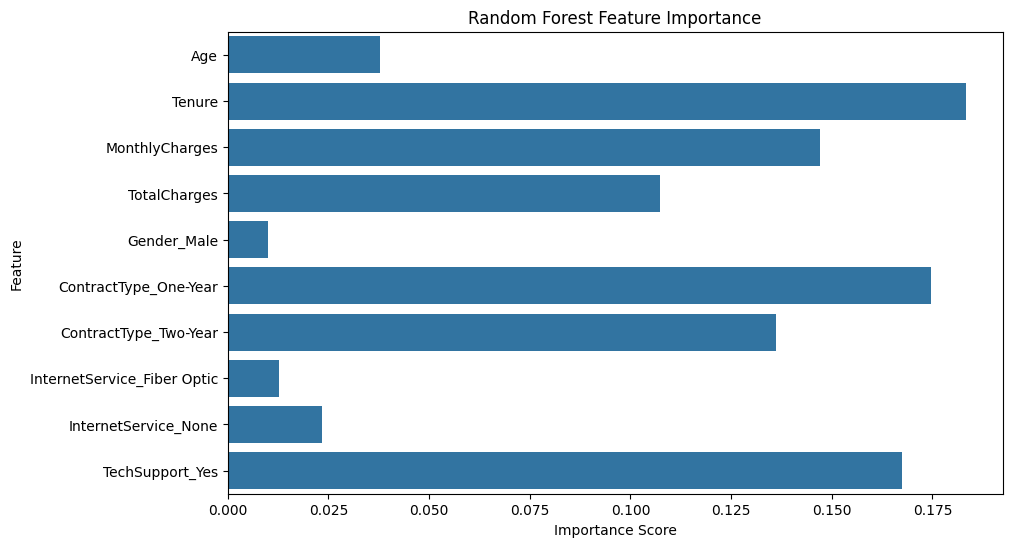

In [138]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

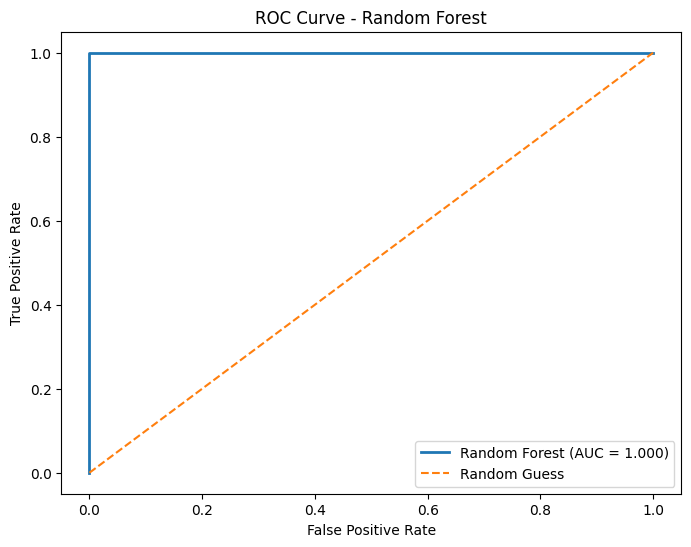

ROC-AUC Score: 1.0


In [140]:
from sklearn.metrics import roc_curve
rf_prob = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)

# ROC Curve points
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')

plt.show()

print("ROC-AUC Score:", rf_auc)


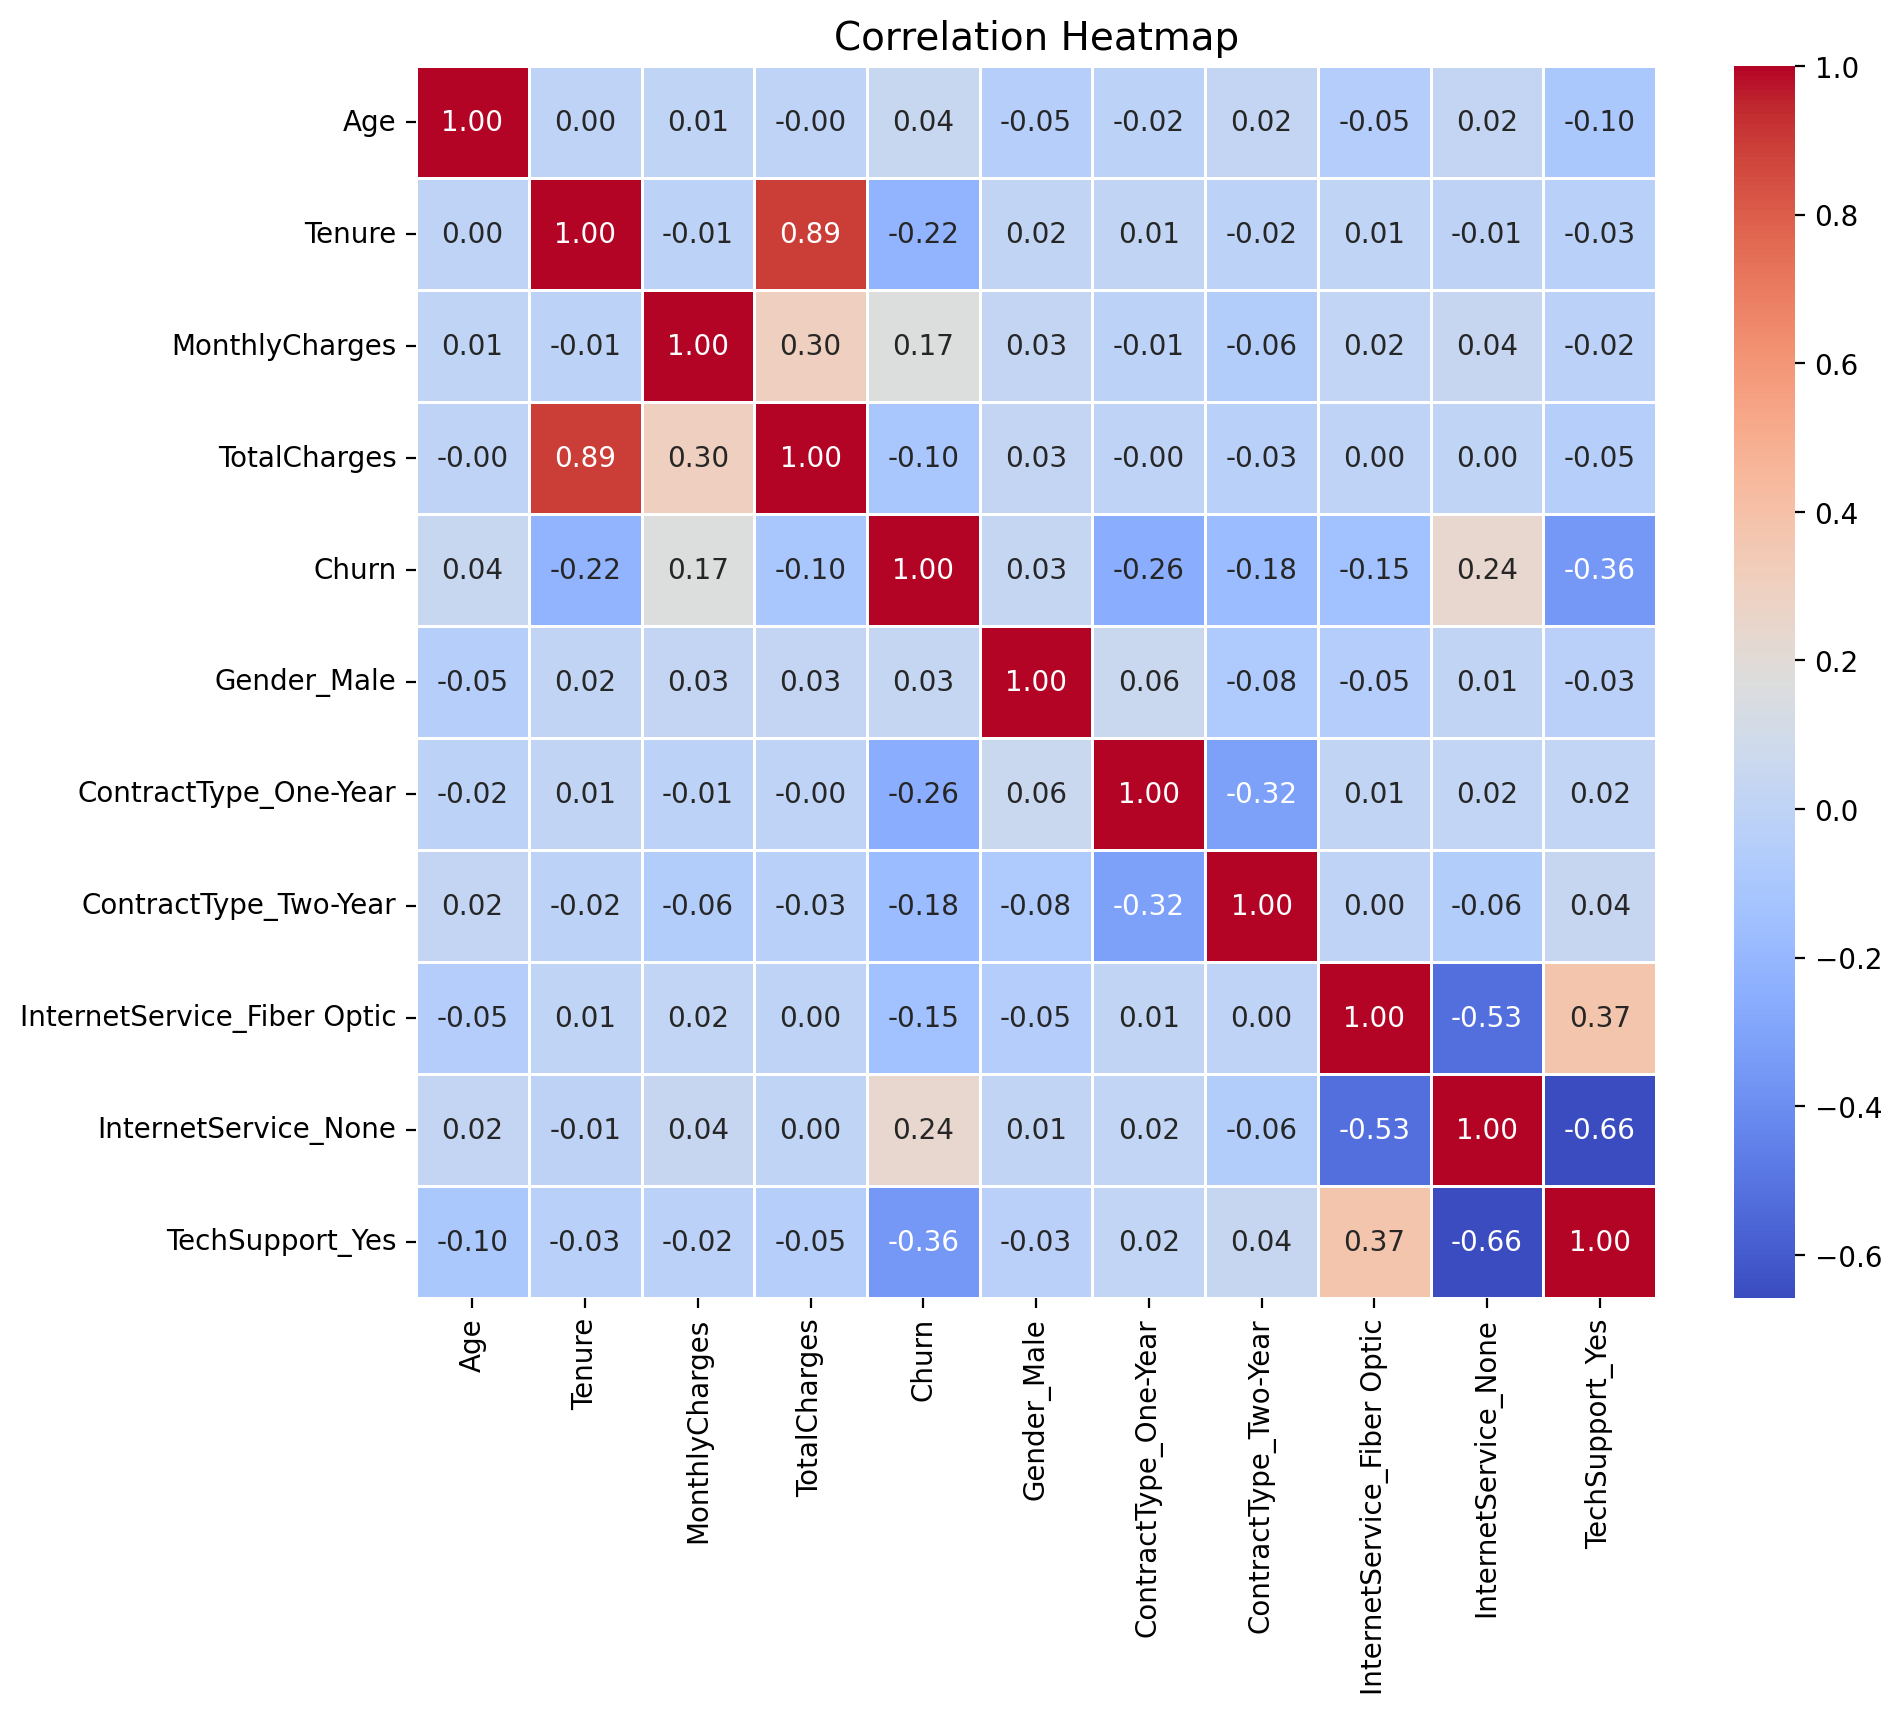

In [144]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8),dpi=200)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=.5
)
plt.title('Correlation Heatmap',fontsize=14)
plt.show()

In [145]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        0.95,
        0.99,
        1.00
    ],
    'Precision': [
        0.97,
        1.00,
        1.00
    ],
    'Recall': [
        0.98,
        0.99,
        1.00
    ],
    'F1-Score': [
        0.97,
        1.00,
        1.00
    ],
    'ROC-AUC': [
        0.9845,
        0.9970,
        1.0000
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.95,0.97,0.98,0.97,0.9845
1,Decision Tree,0.99,1.00,0.99,1.00,0.9970
2,Random Forest,1.00,1.00,1.00,1.00,1.0000


## 🔑 Key Business Insights

1. **Customer Tenure:** Customers with longer tenure show a lower tendency to churn. Tenure has a weak negative correlation with Churn (-0.22), suggesting that customer retention tends to improve as the customer relationship becomes longer.

2. **Contract Type:** Contract length is an important factor in churn prediction. Customers with longer-term contracts showed different churn behavior compared with customers on month-to-month contracts.

3. **Technical Support:** Tech Support was among the most influential features in the tree-based models, indicating that access to technical support may be associated with customer churn behavior.

4. **Monthly Charges:** Monthly Charges have a weak positive correlation with Churn (0.17), suggesting that customers with higher monthly charges may have a slightly higher tendency to churn.

5. **Total Charges:** Total Charges has a strong positive correlation with Tenure (0.89), meaning customers who remain with the company longer generally accumulate higher total charges.

6. **Age:** Age has almost no linear correlation with Churn (0.04), suggesting that age alone is not a strong indicator of churn in this dataset.

7. **Model Performance:** Logistic Regression achieved **95.5% accuracy**, Decision Tree achieved **99.5% accuracy**, and Random Forest achieved **100% accuracy** on the test set. The unusually high performance of the tree-based models should be investigated further for possible data leakage or other data-related issues.

## 📝 Conclusion

This project developed an end-to-end **Customer Churn Prediction** system using Python and machine learning. The workflow included data cleaning, exploratory data analysis, handling missing values, feature encoding, train-test splitting, feature scaling, model training, and model evaluation.

Three classification algorithms were evaluated: **Logistic Regression, Decision Tree, and Random Forest**. Logistic Regression achieved **95.5% accuracy** with a **ROC-AUC of 0.9845**. The Decision Tree achieved **99.5% accuracy** with a **ROC-AUC of 0.997**, while Random Forest achieved **100% accuracy** and a **ROC-AUC of 1.000** on the test set.

The analysis identified **Tenure, Contract Type, Tech Support, Monthly Charges, and Total Charges** as important factors associated with churn behavior. The correlation analysis also showed a strong relationship between Tenure and Total Charges, while Tenure and Monthly Charges showed weaker relationships with Churn.

Although the Random Forest model achieved perfect performance on the test set, these results should be interpreted carefully. The unusually high performance of both tree-based models may indicate **data leakage, duplicate records, or features that indirectly reveal the target variable**. Further validation using cross-validation and additional unseen data would help determine whether the performance generalizes to new customers.

Overall, this project demonstrates a complete **machine learning workflow for customer churn prediction**, combining exploratory data analysis, predictive modeling, model evaluation, and business-oriented insights.

In [146]:
import joblib

joblib.dump(rf, "customer_churn_model.pkl")

['customer_churn_model.pkl']